In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data processing

Import data and join tables

In [2]:
# Import tables from the raw data directory
conditions = pd.read_csv('../raw_data/Conditions.txt', sep='\t')
experiment_conditions = pd.read_csv('../raw_data/ExperimentConditions.txt', sep='\t')
experiments = pd.read_csv('../raw_data/Experiments.txt', sep='\t', encoding='latin1')
logcs = pd.read_csv('../raw_data/LogCs.txt', sep='\t')
properties = pd.read_csv('../raw_data/Properties.txt', sep='\t')
response_properties = pd.read_csv('../raw_data/ResponseProperties.txt', sep='\t')
responses = pd.read_csv('../raw_data/Responses.txt', sep='\t', encoding='latin1')
source = pd.read_csv('../raw_data/Source.txt', sep='\t')

In [3]:
# Transform the LogCs table to have one row per ResponseID with a dictionay
logcs_dict = logcs.groupby('ResponseID').apply(
    lambda x: dict(zip(x['Time'], x['Value']))
).reset_index()

/tmp/ipykernel_22921/4111049196.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  logcs_dict = logcs.groupby('ResponseID').apply(


In [4]:
# Merge the tables to create a single DataFrame for analysis
data = responses.merge(experiments, left_on='ExperimentID', right_on='ID', how='left').drop(columns=['ID_y']).rename(columns={'ID_x': 'ResponseID'})
data = data.merge(experiment_conditions, on='ExperimentID', how='left')
data = data.merge(source, left_on='SourceID', right_on='ID', how='left').drop(columns=['ID'])
data = data.merge(response_properties, on='ResponseID', how='left').rename(columns={'Value_x': 'ResponseValue', 'Value_y': 'ResponsePropertiesValue'})
data = data.merge(conditions, left_on='ConditionID', right_on='ID', how='left').drop(columns=['ID'])
# Wait for this one since I have to look for DART
# data = data.merge(logcs_dict, on='ResponseID', how='left')

In [30]:
data['In_on'].unique()

array(['ground beef salad with mayonnaise', 'ground roast beef slurry',
       'broth', 'ground beef', 'cod',
       'infant formula hydrated with water',
       'infant formula hydrated with milk',
       'infant formula hydratised with apple juice.', 'BHIB',
       'mash carrot', 'milk', 'minced chicken', 'semi-skimmed milk',
       'chicken liver pate', 'BHI broth', 'liquid egg whites',
       'broccoli puree', 'mushroom puree', 'potato puree',
       'potato puree containing cysteine', 'TGYB', 'beef gravy',
       'raw milk', 'yolk', 'MRSB', 'ham', 'water', 'beef', 'TPB',
       'uht milk', 'all beef dog food', 'canned corn', 'chicken roll',
       'pasteurised crabmeat', 'model frankfurter',
       'Chicken nugget meat blend', 'fish', 'scottish pencake',
       'madeira cake', 'non-dairy cream', 'BHI', 'chicken broth',
       'apple juice', 'whole milk', 'skimmed milk', 'peptone solution',
       'quality burger', 'beefburger', 'quality beefbuger',
       'economy beefbuger', 'bee

<Axes: xlabel='Time', ylabel='Count'>

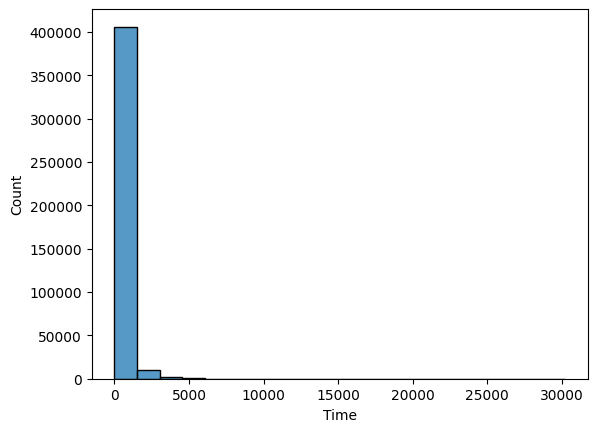

In [10]:
sns.histplot(logcs['Time'], bins=20)

In [12]:
logcs.head()

,ID,ResponseID,Time,Value,ComBaseID
0,1,38694,0.00,4.02,A_1
1,2,38694,22.50,3.99,A_1
2,3,38694,97.75,3.94,A_1
3,4,38694,117.50,3.92,A_1
4,5,38694,144.25,3.78,A_1


In [ ]:
# Determine the maximum time for each ResponseID
test = logcs.groupby('ResponseID')['Time'].max('Time')

In [ ]:
# Determine the number of time points for each ResponseID
test1 = logcs.groupby('ResponseID')['Time'].count()

Text(0, 0.5, 'Frequency')

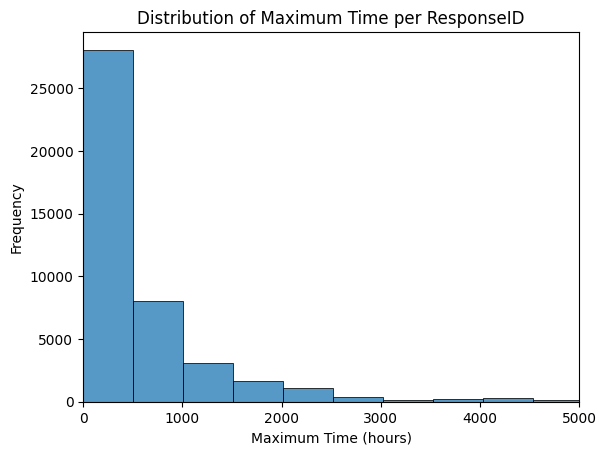

In [26]:
sns.histplot(test, binwidth=500)
plt.xlim(0, 5000)
plt.title('Distribution of Maximum Time per ResponseID')
plt.xlabel('Maximum Time (hours)')
plt.ylabel('Frequency')

In [ ]:
# The majority of the samples have a max time under 1000h. Only those samples
# will be used for the analysis. The rest will be considered outliers and
# removed from the dataset.

<Axes: xlabel='Time', ylabel='Count'>

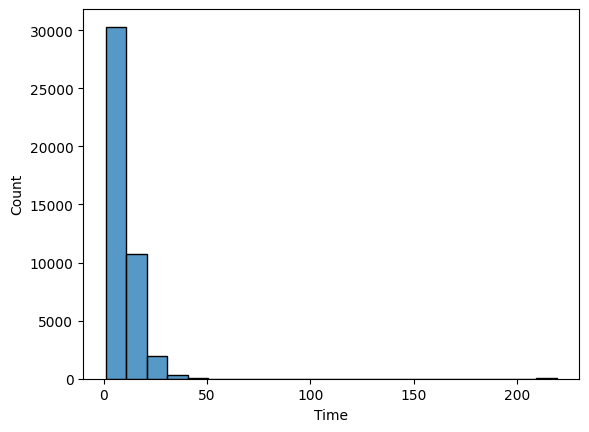

In [21]:
sns.histplot(test1, binwidth=10)